In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
from gymnasium.wrappers import RecordEpisodeStatistics
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import math

/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:55: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation


In [2]:
class BlackjackEnvWithCounting(gym.Env):
    """
    Custom Blackjack environment with card counting.

    State:
      [player_sum, usable_ace, dealer_card, cnt_A, cnt_2, ..., cnt_9, cnt_10group]

      - player_sum: Sum of player's hand (range: 0-28 -> 29 possibilities)
      - usable_ace: 0 (no usable ace) or 1 (at least one ace can be counted as 11)
      - dealer_card: Dealer's face-up card value (1 for Ace, 2–10 for number cards; total 10 possibilities)
      - cnt_A: Count for Ace (0–4; 5 possibilities)
      - cnt_2 to cnt_9: Count for cards 2 through 9 (each 0–4; 5 possibilities each)
      - cnt_10group: Count for 10, Jack, Queen, King (0–16; 17 possibilities)

      Total unique state space: 29*2*10*5*5^8*17 (almost 1e9).
    
    Actions (action_space = Discrete(4)):
      0: HIT      – Request another card.
      1: STK      – Stand (do not take any more cards).
      2: DBL      – Double Down (double wager, take one card then stand).
      3: SUR      – Surrender (forfeit half the wager).

      Note: On the first move, all four actions are available. On subsequent moves, only HIT and STK are allowed.
    
    Reward Structure:
      - Blackjack pays 3:2 (default payout_blackjack=1.5) if only the player has blackjack.
      - Regular win pays 1:1.
      - Push returns 0.
      - Loss costs the bet.
      - Surrender returns -0.5 times the base bet.
      - Double Down outcomes are scaled (bet multiplied by 2).
    """
    
    def __init__(self, payout_blackjack=1.5, deck_threshold=15):
        super(BlackjackEnvWithCounting, self).__init__()
        # Define the action space: 4 discrete actions
        self.action_space = spaces.Discrete(4)
        
        # Updated observation space:
        # [player_sum (29), usable_ace (2), dealer_card (10), cnt_A (5),
        #  cnt_2 ... cnt_9 (each 5) => 8 elements, so total 9 elements for Ace and 2-9,
        #  cnt_10group (17)]
        self.observation_space = spaces.MultiDiscrete([32, 2, 11] + [5]*9 + [17])
        
        self.payout_blackjack = payout_blackjack  # Default payout for natural blackjack (3:2)
        self.base_bet = 1.0
        self.deck_threshold = deck_threshold  # Reshuffle if deck falls below this threshold
        
        # Initialize deck and card counting variables
        self._init_deck()
        self.reset()
        
    def _init_deck(self):
        """Initialize a single deck and reset card counts."""
        # A standard deck: Ace: 4, Cards 2-9: 4 each, 10-group (10, J, Q, K): 16 cards
        self.deck = []
        self.deck += ['A'] * 4
        for card in range(2, 10):
            self.deck += [str(card)] * 4
        self.deck += ['10'] * 16  # Represents 10, Jack, Queen, King
        
        random.shuffle(self.deck)
        
        # Initialize card counts (tracking the number of times each card has been seen)
        self.card_counts = {'A': 0}
        for card in range(2, 10):
            self.card_counts[str(card)] = 0
        self.card_counts['10'] = 0
        
    def _draw_card(self):
        """Draw a card from the deck and update the card count."""
        if len(self.deck) == 0:
            # If deck is empty, reinitialize (reshuffle)
            self._init_deck()
        card = self.deck.pop()
        
        # Update counts (capped by maximum available in a single deck)
        if card == 'A':
            self.card_counts['A'] = min(self.card_counts['A'] + 1, 4)
        elif card == '10':
            self.card_counts['10'] = min(self.card_counts['10'] + 1, 16)
        else:
            self.card_counts[card] = min(self.card_counts[card] + 1, 4)
        return card
    
    def _hand_value(self, hand):
        """Compute the sum of a hand and determine if a usable ace exists."""
        total = 0
        ace_count = 0
        for card in hand:
            if card == 'A':
                total += 1
                ace_count += 1
            else:
                total += int(card)
        usable_ace = 0
        # If an ace can be used as 11 without busting, adjust total.
        if ace_count > 0 and total + 10 <= 21:
            total += 10
            usable_ace = 1
        return total, usable_ace
    
    def _card_value(self, card):
        """Return the blackjack value for a given card (used for dealer's face-up card)."""
        if card == 'A':
            return 1  # For decision-making; Ace may later be counted as 11.
        else:
            return int(card)
    
    def _get_observation(self):
        """
        Construct the observation vector:
          [player_sum, usable_ace, dealer_card, cnt_A, cnt_2, ..., cnt_9, cnt_10group]
        """
        player_sum, usable_ace = self._hand_value(self.player_hand)
        dealer_face_up = self.dealer_hand[0]
        dealer_card_val = self._card_value(dealer_face_up)
        
        # Order of card counts: Ace, 2,3,...,9, 10-group.
        counts = []
        counts.append(self.card_counts['A'])  # Count for Ace (0-4)
        for card in range(2, 10):
            counts.append(self.card_counts[str(card)])
        counts.append(self.card_counts['10'])  # Count for 10-group (0-16)
        
        obs = np.array([player_sum, usable_ace, dealer_card_val] + counts, dtype=np.int32)
        return obs
    
    def reset(self, seed=None, options=None):
        """
        Reset the environment to start a new round.
        Returns:
          observation, info
        """
        self.first_move = True  # Flag to track if it's the first move (allows DBL and SUR)
        self.done = False
        
        # Reshuffle deck if running low.
        if len(self.deck) < self.deck_threshold:
            self._init_deck()
        
        # Deal two cards each for player and dealer.
        self.player_hand = [self._draw_card(), self._draw_card()]
        self.dealer_hand = [self._draw_card(), self._draw_card()]
        
        # Check for natural blackjack in player's hand.
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        
        if player_total == 21:
            if dealer_total == 21:
                self.done = True
                self.reward = 0.0
            else:
                self.done = True
                self.reward = self.payout_blackjack * self.base_bet
        else:
            self.reward = 0.0
            
        return self._get_observation(), {}
    
    def step(self, action):
        """
        Take an action and update the environment.
        Returns:
          observation, reward, terminated, truncated, info
        """
        # If already done, return current state.
        if self.done:
            return self._get_observation(), 0.0, True, False, {}
        
        # On moves after the first, only HIT (0) and STK (1) are allowed.
        if not self.first_move and action in [2, 3]:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
        
        if action == 0:  # HIT
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                # Player busts.
                self.done = True
                reward = -self.base_bet
            else:
                reward = 0.0
            self.first_move = False
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 1:  # STK (Stand)
            reward = self._dealer_play()
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 2:  # DBL (Double Down)
            self.first_move = False
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                reward = -2 * self.base_bet
                self.done = True
                return self._get_observation(), reward, self.done, False, {}
            # After drawing one card, the player stands.
            reward = self._dealer_play(double_down=True)
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 3:  # SUR (Surrender)
            self.first_move = False
            self.done = True
            reward = -0.5 * self.base_bet
            return self._get_observation(), reward, self.done, False, {}
        
        else:
            # Invalid action.
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
    
    def _dealer_play(self, double_down=False):
        """
        Simulate the dealer's turn after the player stands (or double downs).
        Dealer reveals the hidden card and draws until reaching at least 17.
        Returns the reward based on the outcome.
        """
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        
        # Dealer draws until reaching a total of 17 or more.
        while dealer_total < 17:
            card = self._draw_card()
            self.dealer_hand.append(card)
            dealer_total, _ = self._hand_value(self.dealer_hand)
        
        bet = self.base_bet * (2 if double_down else 1)
        
        if dealer_total > 21:
            return bet
        elif dealer_total > player_total:
            return -bet
        elif dealer_total < player_total:
            return bet
        else:
            return 0.0  # Push
    
    def render(self, mode='human'):
        """Simple rendering of the current state."""
        player_total, usable = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        print(f"Player hand: {self.player_hand} (Total: {player_total}, Usable Ace: {usable})")
        print(f"Dealer hand: {self.dealer_hand} (Total: {dealer_total})")
        print("Card counts:", self.card_counts)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(


Episode: 100000, Total Reward: -21179.50, Total Bet: 108184.00, Reward/Bet Ratio: -19.58%
Episode: 200000, Total Reward: -32564.50, Total Bet: 217396.00, Reward/Bet Ratio: -14.98%
Episode: 300000, Total Reward: -42472.00, Total Bet: 326891.00, Reward/Bet Ratio: -12.99%
Episode: 400000, Total Reward: -52244.50, Total Bet: 436637.00, Reward/Bet Ratio: -11.97%
Episode: 500000, Total Reward: -61797.00, Total Bet: 546816.00, Reward/Bet Ratio: -11.30%
Episode: 600000, Total Reward: -71630.50, Total Bet: 655316.00, Reward/Bet Ratio: -10.93%
Episode: 700000, Total Reward: -81978.50, Total Bet: 761694.00, Reward/Bet Ratio: -10.76%
Episode: 800000, Total Reward: -91149.00, Total Bet: 869004.00, Reward/Bet Ratio: -10.49%
Episode: 900000, Total Reward: -100299.50, Total Bet: 978080.00, Reward/Bet Ratio: -10.25%
Episode: 1000000, Total Reward: -109057.00, Total Bet: 1087531.00, Reward/Bet Ratio: -10.03%
Episode: 1100000, Total Reward: -117885.00, Total Bet: 1197145.00, Reward/Bet Ratio: -9.85%
Epis

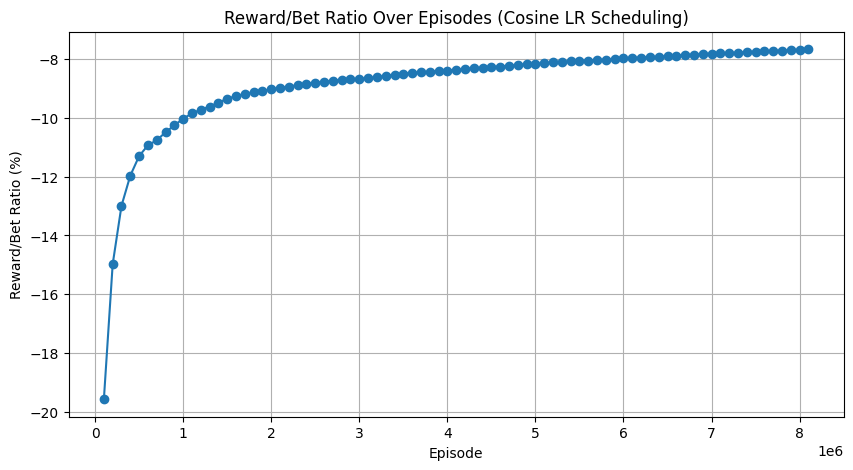

In [3]:
# ----------------------------
# Define a Cosine Learning Rate Schedule
# ----------------------------
def cosine_lr_schedule(progress_remaining):
    """
    Cosine learning rate schedule.
    progress_remaining: float in [0,1], where 1.0 is the start and 0.0 is the end.
    Decays the learning rate from 1e-4 to 1e-6 following a cosine schedule.
    """
    lr_initial = 1e-4
    lr_min = 1e-6
    cosine_decay = 0.5 * (1 + math.cos(math.pi * (1 - progress_remaining)))
    return lr_min + (lr_initial - lr_min) * cosine_decay

# ----------------------------
# Custom Wrapper to Attach Bet Info
# ----------------------------
class BetInfoWrapper(gym.Wrapper):
    """
    A gym Wrapper that records the bet placed in an episode.
    For terminal episodes, it adds a key "bet" to the info dictionary.
    Assumes that if the last action was DBL (2), then bet=2.0; otherwise, bet=1.0.
    """
    def __init__(self, env):
        super(BetInfoWrapper, self).__init__(env)
    
    def step(self, action):
        self.last_action = action  # store last action taken
        obs, reward, terminated, truncated, info = self.env.step(action)
        if terminated or truncated:
            info["bet"] = 2.0 if self.last_action == 2 else 1.0
        return obs, reward, terminated, truncated, info

# ----------------------------
# Custom Callback for Training Metrics
# ----------------------------
class TrainingMetricsCallback(BaseCallback):
    """
    Custom callback that logs and stores the reward-to-bet ratio every 'print_freq' episodes.
    The metric is computed as:
      (Total reward across episodes / Total bet placed across episodes) * 100.
    """
    def __init__(self, print_freq=100_000, verbose=0):
        super(TrainingMetricsCallback, self).__init__(verbose)
        self.print_freq = print_freq
        self.total_reward = 0.0
        self.total_bet = 0.0
        self.episode_count = 0
        self.episode_history = []
        self.ratio_history = []
    
    def _on_step(self) -> bool:
        infos = self.locals.get("infos", None)
        if infos is not None:
            if isinstance(infos, list):
                for info in infos:
                    if "episode" in info:
                        self.episode_count += 1
                        self.total_reward += info["episode"]["r"]
                        self.total_bet += info.get("bet", 1.0)
                        if self.episode_count % self.print_freq == 0:
                            ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                            print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, "
                                  f"Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                            self.episode_history.append(self.episode_count)
                            self.ratio_history.append(ratio)
            else:
                if "episode" in infos:
                    self.episode_count += 1
                    self.total_reward += infos["episode"]["r"]
                    self.total_bet += infos.get("bet", 1.0)
                    if self.episode_count % self.print_freq == 0:
                        ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                        print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, "
                              f"Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                        self.episode_history.append(self.episode_count)
                        self.ratio_history.append(ratio)
        return True

# ----------------------------
# Create the Environment and Wrap It
# ----------------------------
# Note: Replace 'BlackjackEnvWithCounting' with your actual blackjack environment class.
env = BlackjackEnvWithCounting()
env = BetInfoWrapper(env)
env = RecordEpisodeStatistics(env)  # This wrapper records episode info into the "episode" key

# (Optional) Check that the environment follows Gymnasium's API
check_env(env, warn=True)

# ----------------------------
# Initialize the PPO Agent
# ----------------------------
model = PPO(
    "MlpPolicy",
    env,
    gamma=0.99,
    learning_rate=cosine_lr_schedule,  # Use the cosine learning rate schedule
    verbose=0,  # Suppress default logs; we only want our custom metric printed.
    n_steps=2048,
    batch_size=64,
    ent_coef=0.01,
)

# Create the training metrics callback instance (prints every 100,000 episodes)
metrics_callback = TrainingMetricsCallback(print_freq=100_000, verbose=0)

# ----------------------------
# Train the Model
# ----------------------------
model.learn(total_timesteps=10_000_000, callback=metrics_callback)

# Save the trained model (optional)
model.save("ppo_blackjack_model_cosine_lr")
print("Model training complete and saved as 'ppo_blackjack_model_cosine_lr'.")

# ----------------------------
# Plot the Reward/Bet Ratio Over Episodes
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(metrics_callback.episode_history, metrics_callback.ratio_history, marker='o', linestyle='-')
plt.title("Reward/Bet Ratio Over Episodes (Cosine LR Scheduling)")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/save_util.py:437: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arb

Starting evaluation...
Episode 1000: Reward/Bet Ratio = -7.15%
Episode 2000: Reward/Bet Ratio = -5.46%
Episode 3000: Reward/Bet Ratio = -6.59%
Episode 4000: Reward/Bet Ratio = -5.94%
Episode 5000: Reward/Bet Ratio = -6.72%
Episode 6000: Reward/Bet Ratio = -6.82%
Episode 7000: Reward/Bet Ratio = -6.75%
Episode 8000: Reward/Bet Ratio = -7.06%
Episode 9000: Reward/Bet Ratio = -7.07%
Episode 10000: Reward/Bet Ratio = -6.77%
Episode 11000: Reward/Bet Ratio = -6.86%
Episode 12000: Reward/Bet Ratio = -7.05%
Episode 13000: Reward/Bet Ratio = -7.21%
Episode 14000: Reward/Bet Ratio = -6.91%
Episode 15000: Reward/Bet Ratio = -7.25%
Episode 16000: Reward/Bet Ratio = -7.12%
Episode 17000: Reward/Bet Ratio = -7.38%
Episode 18000: Reward/Bet Ratio = -7.39%
Episode 19000: Reward/Bet Ratio = -7.03%
Episode 20000: Reward/Bet Ratio = -6.72%
Episode 21000: Reward/Bet Ratio = -6.51%
Episode 22000: Reward/Bet Ratio = -6.42%
Episode 23000: Reward/Bet Ratio = -6.30%
Episode 24000: Reward/Bet Ratio = -6.29%
Ep

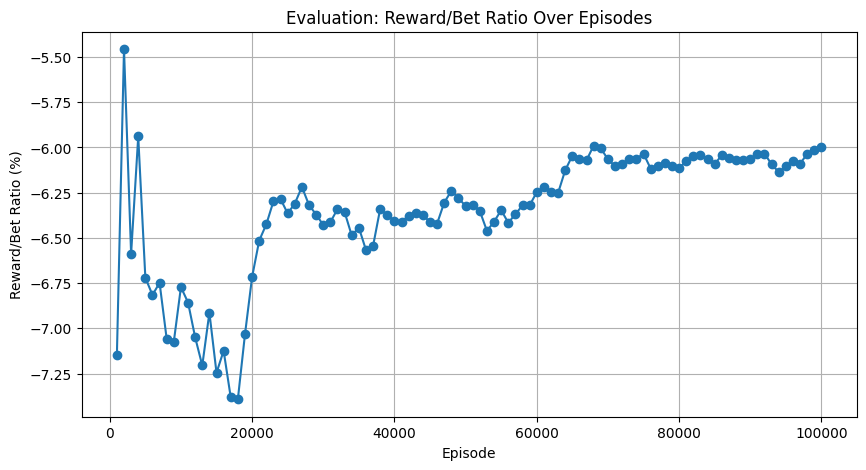

In [4]:
# Create the evaluation environment with the same wrappers
eval_env = BlackjackEnvWithCounting()
eval_env = BetInfoWrapper(eval_env)
eval_env = RecordEpisodeStatistics(eval_env)

# Load the trained model (adjust the path if needed)
model = PPO.load("ppo_blackjack_model_cosine_lr", env=eval_env)

# Evaluation settings
num_episodes = 100_000
reward_history = []  # store final reward for each episode
bet_history = []     # store bet placed for each episode
ratio_history_eval = []  # to store cumulative reward/bet ratio every 1000 episodes
episode_x = []           # episode numbers at which ratio is recorded

# Counters for win/draw/loss outcomes
wins = 0
draws = 0
losses = 0

print("Starting evaluation...")
for episode in range(1, num_episodes + 1):
    obs, _ = eval_env.reset()
    done = False

    # Run an episode until termination
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = eval_env.step(action)
    
    # The environment returns the final reward on termination
    episode_reward = reward
    # Retrieve the bet info (from our BetInfoWrapper) from the final info dict; default to 1.0 if missing.
    episode_bet = info.get("bet", 1.0)
    
    reward_history.append(episode_reward)
    bet_history.append(episode_bet)
    
    # Classify outcome: win if reward > 0, draw if reward == 0, loss if reward < 0.
    if episode_reward > 0:
        wins += 1
    elif episode_reward == 0:
        draws += 1
    else:
        losses += 1
    
    # Every 1000 episodes, compute the cumulative reward-to-bet ratio and record it
    if episode % 1000 == 0:
        total_reward = np.sum(reward_history)
        total_bet = np.sum(bet_history)
        ratio = (total_reward / total_bet * 100) if total_bet > 0 else 0.0
        ratio_history_eval.append(ratio)
        episode_x.append(episode)
        print(f"Episode {episode}: Reward/Bet Ratio = {ratio:.2f}%")

# Compute overall win, draw, and loss percentages
win_percent = wins / num_episodes * 100
draw_percent = draws / num_episodes * 100
loss_percent = losses / num_episodes * 100

print("\nFinal Evaluation Results:")
print(f"Win %: {win_percent:.2f}%")
print(f"Draw %: {draw_percent:.2f}%")
print(f"Loss %: {loss_percent:.2f}%")

# Plot the reward-to-bet ratio over evaluation episodes
plt.figure(figsize=(10, 5))
plt.plot(episode_x, ratio_history_eval, marker='o', linestyle='-')
plt.title("Evaluation: Reward/Bet Ratio Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()